# Nonlinear Regression and Forecasting

## Will a new video keep gaining views?

A clip can gain views quickly and then slow down as fewer interested viewers remain. A saturation curve represents this pattern with an eventual audience size and a spread rate.

<img src="https://raw.githubusercontent.com/sonamu-jun/introduction-to-ai-convergence/main/06-1_Regression/assets/05_video_reach.png" alt="A simulated video gains views quickly, then approaches an audience ceiling as fewer interested viewers remain." width="640" style="max-width:100%;height:auto;">

The audience control changes the curve's ceiling. The spread-rate control changes how quickly it approaches that ceiling. These quantities interact, making the model nonlinear in its parameters. A curved line alone does not make a model nonlinear; polynomial regression uses curved features with linear coefficients.

Filled dots are synthetic view counts during the first 12 hours. Open dots show predictions at the same times. The gaps reveal whether the selected curve follows those records. A video need not follow this pattern in reality: a repost can introduce a new audience.


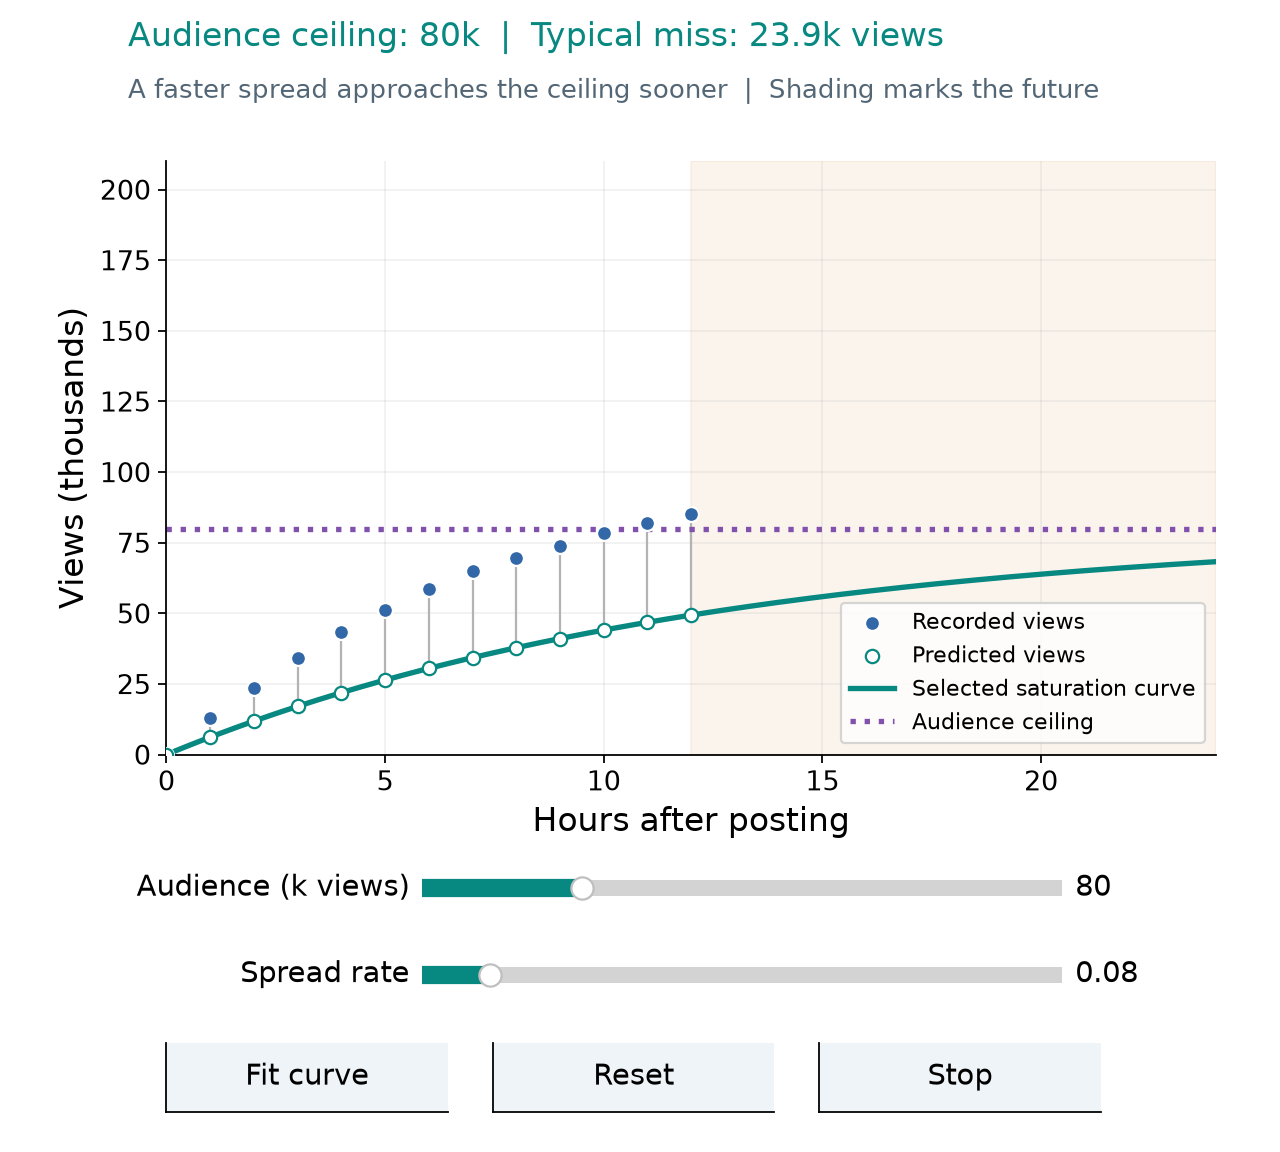

In [1]:
import os
import sys
import io
import numpy as np
import pandas as pd
import matplotlib

REGRESSION_STATIC = os.environ.get("REGRESSION_STATIC") == "1"
REGRESSION_BROWSER = sys.platform == "emscripten"
if not REGRESSION_STATIC and not REGRESSION_BROWSER:
    from IPython import get_ipython
    shell = get_ipython()
    if shell is not None and getattr(shell, "kernel", None) is not None:
        shell.run_line_magic("matplotlib", "widget")

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.patches import Rectangle
from IPython.display import Image, display
from sklearn.linear_model import LinearRegression

plt.rcParams.update({
    "font.size": 15, "axes.labelsize": 15,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "lines.linewidth": 2.4,
    "axes.unicode_minus": False, "figure.facecolor": "white",
})
BLUE, TEAL, ORANGE, PURPLE = "#3268a8", "#078880", "#d87522", "#8251ac"


def metrics(observed, predicted):
    """R² is undefined for a constant evaluation target."""
    observed = np.asarray(observed, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    error = observed - predicted
    mse = np.mean(error**2)
    total = np.sum((observed - observed.mean())**2)
    return {"MAE": np.mean(np.abs(error)), "MSE": mse,
            "RMSE": np.sqrt(mse),
            "R²": 1 - np.sum(error**2) / total if total > 0 else np.nan}


# Close earlier views before replacing models or shared callbacks on a rerun.
for _previous_view in globals().get("_regression_views", {}).values():
    _previous_view.close()
_regression_views = {}


class RegressionExplorer:
    """Sliders redraw the model and its metrics from the same observations."""

    def __init__(self, name, render, sliders, actions=(), history=False):
        previous = _regression_views.get(name)
        if previous is not None:
            previous.close()
        self.render = render
        self.running = False
        self.controls, self.buttons, self.state = {}, {}, {}
        self.defaults = {key: initial for key, label, low, high, initial, step, fmt in sliders}
        # 80 dpi gives a 640 px live canvas; saved output uses 160 dpi at the same display size.
        with plt.ioff():
            self.figure = plt.figure(figsize=(8, 8.4 if history else 7.2), dpi=80)
        self.status = self.figure.text(.10, .96, "", fontsize=15, color=TEAL)
        self.detail = self.figure.text(.10, .915, "", fontsize=11.5, color="#536675")
        bottom = .27 + .075 * (len(sliders) - 1)
        if history:
            self.ax = self.figure.add_axes([.13, .56, .82, .30])
            self.history_ax = self.figure.add_axes([.13, .33, .82, .12])
        else:
            self.ax = self.figure.add_axes([.13, bottom, .82, .86 - bottom])
        for i, (key, label, low, high, initial, step, fmt) in enumerate(sliders):
            y = .14 + .075 * (len(sliders) - i - 1)
            slider = Slider(self.figure.add_axes([.33, y, .50, .028]),
                            label, low, high, valinit=initial, valstep=step,
                            valfmt=fmt, color=TEAL)
            slider.label.set_fontsize(13)
            slider.valtext.set_fontsize(13)
            slider.on_changed(self.update)
            self.controls[key] = slider
        commands = list(actions) + [("Reset", lambda view: view.reset()),
                                    ("Stop", lambda view: view.stop())]
        width = min(.22, .8 / len(commands) - .025)
        for i, (label, callback) in enumerate(commands):
            button = Button(self.figure.add_axes([.13 + i*(width+.035), .035, width, .06]),
                            label, color="#eef4f7", hovercolor="#d7e9e6")
            button.label.set_fontsize(13)
            button.on_clicked(lambda event, callback=callback: callback(self))
            self.buttons[label] = button
        self.figure.canvas.mpl_connect("close_event", lambda event: self.stop())
        _regression_views[name] = self
        self.update()

    def update(self, _=None):
        self.ax.clear()
        if hasattr(self, "history_ax"):
            self.history_ax.clear()
        values = {key: slider.val for key, slider in self.controls.items()}
        self.state = self.render(self, **values)
        self.figure.canvas.draw_idle()

    def set_values(self, **values):
        for key, value in values.items():
            slider = self.controls[key]
            events, drawing = slider.eventson, slider.drawon
            slider.eventson = slider.drawon = False
            slider.set_val(value)
            slider.eventson, slider.drawon = events, drawing
        self.update()

    def reset(self):
        self.set_values(**self.defaults)

    def start(self):
        if REGRESSION_STATIC:
            buffer = io.BytesIO()
            self.figure.savefig(buffer, format="png", dpi=160, facecolor="white")
            display(Image(data=buffer.getvalue(), width=640,
                          alt=self.status.get_text() + ". " + self.detail.get_text()))
            plt.close(self.figure)
            return
        self.running = True
        if REGRESSION_BROWSER:
            # The browser dispatches input after the cell returns.
            plt.show(block=False)
        elif hasattr(self.figure.canvas, "toolbar_visible"):
            self.figure.canvas.toolbar_visible = False
            self.figure.canvas.header_visible = False
            self.figure.canvas.footer_visible = False
            self.figure.canvas.resizable = False
            display(self.figure.canvas)
        else:
            plt.show(block=False)

    def stop(self):
        self.running = False
        for slider in self.controls.values():
            slider.set_active(False)
        for button in self.buttons.values():
            button.set_active(False)
        self.buttons["Stop"].label.set_text("Stopped")
        self.figure.canvas.draw_idle()

    def close(self):
        self.stop()
        plt.close(self.figure)

rng_video = np.random.default_rng(62)
reach_scale, time_scale = 120., 12.
video_time = np.arange(25, dtype=float)


def video_mean(time):
    return 120 * (1-np.exp(-.13*np.asarray(time)))


# Positive hourly increments keep the synthetic cumulative count monotone.
expected_increments = np.diff(video_mean(video_time))
recorded_increments = expected_increments * np.clip(1+rng_video.normal(0, .12, 24), .3, 1.7)
video_observed = np.r_[0., np.cumsum(recorded_increments)]
video_time_train, video_views_train = video_time[:13], video_observed[:13]
video_grid = np.linspace(0, 24, 300)
u_train, z_train = video_time_train/time_scale, video_views_train/reach_scale


def video_curve(time, reach, rate):
    return reach * (1-np.exp(-rate*np.asarray(time)))


def video_loss_gradient(parameters):
    a, b = parameters
    remaining = np.exp(-b*u_train)
    error = a*(1-remaining)-z_train
    gradient = 2*np.array([np.mean(error*(1-remaining)), np.mean(error*a*u_train*remaining)])
    return float(np.mean(error**2)), gradient


def fit_video(initial=(.6, .5), step_size=.08, steps=3000):
    parameters = np.array(initial, dtype=float)
    history = []
    for _ in range(steps):
        loss, gradient = video_loss_gradient(parameters)
        history.append([*parameters, loss])
        # Physical bounds exclude a negative audience or a negative spread rate.
        parameters = np.clip(parameters-step_size*gradient, [.05, .03], [4., 12.])
    loss, _ = video_loss_gradient(parameters)
    history.append([*parameters, loss])
    return np.asarray(history)


video_runs = [fit_video(initial) for initial in [(.6, .5), (1.5, 2.), (1., 1.)]]
video_reference = min(video_runs, key=lambda history: history[-1, 2])
reach_fit, rate_fit = video_reference[-1, 0]*reach_scale, video_reference[-1, 1]/time_scale




def video_records(ax, predicted=None):
    ax.scatter(video_time_train, video_views_train, color=BLUE, edgecolor="white", s=45,
               label="Recorded views", zorder=4)
    if predicted is not None:
        ax.vlines(video_time_train, predicted, video_views_train, color=".7", linewidth=1)
        ax.scatter(video_time_train, predicted, facecolors="white", edgecolors=TEAL, s=36,
                   label="Predicted views", zorder=5)
    ax.set(xlabel="Hours after posting", ylabel="Views (thousands)")


def render_video_shape(view, reach, rate):
    prediction = video_curve(video_grid, reach, rate)
    predicted_train = video_curve(video_time_train, reach, rate)
    error = metrics(video_views_train, predicted_train)
    ax = view.ax
    video_records(ax, predicted_train)
    ax.plot(video_grid, prediction, color=TEAL, label="Selected saturation curve")
    ax.axhline(reach, color=PURPLE, linestyle=":", label="Audience ceiling")
    ax.axvspan(12, 24, color=ORANGE, alpha=.08)
    ax.set(xlim=(0, 24), ylim=(0, 210))
    ax.legend(loc="lower right", fontsize=10)
    view.status.set_text(f"Audience ceiling: {reach:.0f}k  |  Typical miss: {error['MAE']:.1f}k views")
    view.detail.set_text("A faster spread approaches the ceiling sooner  |  Shading marks the future")
    return {"prediction": prediction, "training_prediction": predicted_train, "metrics": error}


video_shape_demo = RegressionExplorer("video_shape", render_video_shape, [
    ("reach", "Audience (k views)", 40, 200, 80, 5, "%0.0f"),
    ("rate", "Spread rate", .03, .5, .08, .01, "%0.2f"),
], actions=[("Fit curve", lambda view: view.set_values(reach=reach_fit, rate=rate_fit))])
video_shape_demo.start()


## Fitting the curve and forecasting

`Fit curve` applies the fitted audience ceiling and spread rate. Gradient descent repeatedly adjusts both parameters using the gradient of squared error. Step size determines how far each update moves; overly large steps can overshoot. The code uses fixed steps and compares three starting points, keeping the final fit with the lowest training cost. Several starts do not prove that the best possible nonlinear fit has been found.

Only the first 12 hours are used for fitting. The curve beyond the shaded boundary is a forecast under the same saturation assumption. A straight line would keep adding views at a constant pace; this curve slows down as the remaining audience shrinks. Later observations must stay out of fitting if they are to test the forecast.


## An unexpected new audience

A future repost can bring viewers who were absent from the recorded pattern. The curve has no input describing that event, so fitting the past more closely cannot anticipate its timing or size. New observations or an input describing reposts would supply missing information. The forecast remains an estimate under assumptions.
